### Subagents
A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions.
This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

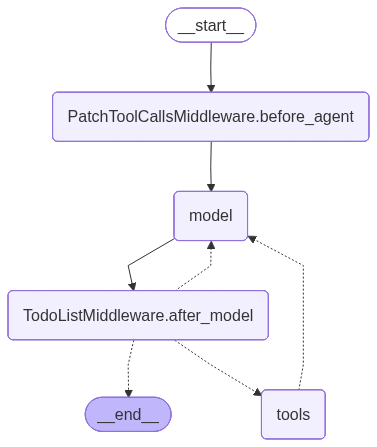

In [4]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:qwen/qwen3-32b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="openai:gpt-5.4",
    subagents=subagents
)
agent


In [5]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================

[{'arguments': '{"todos":[{"content":"Research LLM gateways: definitions, capabilities, vendors, architectures, tradeoffs, and use cases","status":"in_progress"},{"content":"Synthesize findings into a detailed structured summary with recommendations and evaluation criteria","status":"pending"}]}', 'call_id': 'call_1Tsqtrx6vGERvieVkfzZDOfr', 'name': 'write_todos', 'type': 'function_call', 'id': 'fc_0b2a2df563fbc2fc006a2179d475a88192b9090e73857afff8', 'status': 'completed'}]
Tool Calls:
  write_todos (call_1Tsqtrx6vGERvieVkfzZDOfr)
 Call ID: call_1Tsqtrx6vGERvieVkfzZDOfr
  Args:
    todos: [{'content': 'Research LLM gateways: definitions, capabilities, vendors, architectures, tradeoffs, and use cases', 'status': 'in_progress'}, {'content': 'Synthesize findings into

### structured Output With Sub Agents

In [6]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model="openai:gpt-5.4",
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [ ]:
# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================

[{'arguments': '{"description":"Research recent advances in quantum computing as of 2024–2026. Focus on major technical and industry developments across hardware, error correction/fault tolerance, algorithms/software, networking/communication, and commercial ecosystem. Return a concise but substantive report with: (1) 8–12 key advances, each with 1–2 sentence explanation and why it matters, (2) notable companies/labs involved, (3) important caveats or hype-vs-reality notes, and (4) a short outlook for the next 2–3 years. Prefer broadly accepted developments over speculative claims.","subagent_type":"researcher"}', 'call_id': 'call_DYex72VmJwnTLwhVH0KvKqLl', 'name': 'task', 'type': 'function_call', 'id': 'fc_002275fbc97879a6006a217b277be081a3a440a14570a0a25f', 'status': 'completed

: 